In [9]:
import pandas as pd
import yfinance as yf 
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt 
import mplfinance as mpf

In [10]:
start = dt.datetime(2025,1,1)
end = dt.datetime(2025,3,31)

In [11]:
def OBV(start,end,ticker):
    df = yf.download(ticker,start,end)
    df.columns = df.columns.droplevel(1)
    conditions = [(df['Close']>df['Open']),(df['Close']<df['Open']),(df['Close']==df['Open'])]
    choices = [df['Volume'],-1*df['Volume'],0]
    df['OBV'] = np.select(conditions, choices, default='Unknown')
    df['OBV']=df['OBV'].astype(float).cumsum()
    fig,ax1 = plt.subplots()
    ax1.plot(df['Close'],ms=2.0,label='Close Price')
    ax1.plot(df['Close'],'ro')
    plt.legend(loc='upper left')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price')
    ax2 = ax1.twinx()
    ax2.plot(df['OBV'],'g',lw=1.5,ms=10,label='OBV')
    ax2.plot(df['OBV'],'bo')
    ax2.legend(loc='upper right')
    ax2.set_ylabel('OBV')
    plt.title('Volume Indicator');
    my_colors = mpf.make_marketcolors(
        up='green',
        down='red',
        edge='black',
        wick='black',
        volume='Blue' # Optional: Color for the volume bars
    )
    my_style = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=my_colors)

    mpf.plot(df,type='candle',volume=True,style=my_style)




[*********************100%***********************]  1 of 1 completed


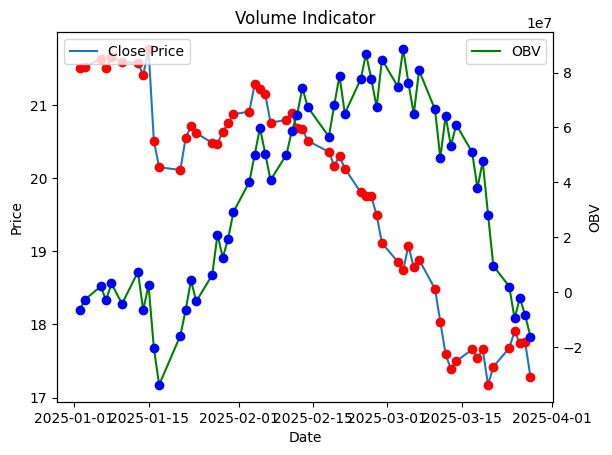

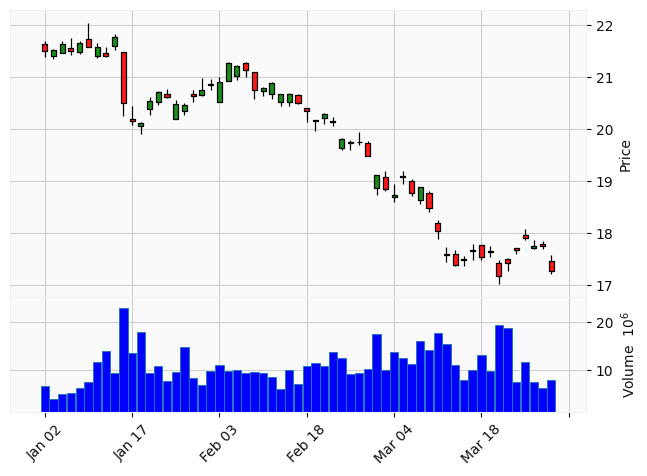

In [12]:
OBV(start,end,'INFY')